In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from utils.fingerprinter import Fingerprinter
from utils.visualization import plot_regression_histograms

import torch
from utils.mlp import MLP

%load_ext autoreload
%autoreload 2

## Datasets

In [2]:
train = pd.read_csv('../train_clean.csv')
test = pd.read_csv('../test_clean.csv')
properties = train.columns[1:]

In [3]:
fingerprinter = Fingerprinter()

train_X = torch.tensor(
    fingerprinter(train['SMILES'].tolist()), 
    dtype=torch.float32, 
    requires_grad=False
)
test_X = torch.tensor(
    fingerprinter(test['SMILES'].tolist()), 
    dtype=torch.float32, 
    requires_grad=False
)

n_features = train_X.shape[1]
print(f'Fingerprints have {n_features} features')

Fingerprints have 2048 features


## MLP Model

In [4]:
params = dict(
    n_features=n_features, 
    depth=4, 
    width=64, 
    lr=0.001, 
    weight_decay=0.01
)

mlp_dict = {property_label : MLP(**params)
            for property_label in properties}

In [5]:
for property_label, mlp in mlp_dict.items():

    print(f'Training MLP for {property_label}...', end='')
    
    train_Y = torch.tensor(
        train[property_label], 
        dtype=torch.float32, 
        requires_grad=False
    )
    loss = mlp.fit(train_X, train_Y)

    print('Done (Loss = {:.5f})'.format(loss))

Training MLP for Viability Mask 1...Done (Loss = 0.33805)
Training MLP for Viability Mask 2...Done (Loss = 0.29105)
Training MLP for LPS Abs...Done (Loss = 0.99909)
Training MLP for LPS Lum...Done (Loss = 1.00104)
Training MLP for MPLA Abs...Done (Loss = 0.99956)
Training MLP for MPLA Lum...Done (Loss = 0.99989)
Training MLP for CpG Abs...Done (Loss = 0.99924)
Training MLP for cGAMP Abs...Done (Loss = 0.99907)
Training MLP for cGAMP Lum...Done (Loss = 0.41959)
Training MLP for LMCpG Abs...Done (Loss = 1.00015)
Training MLP for LMcGAMP Lum...Done (Loss = 1.00001)


ValueError: `bins` must be positive, when an integer

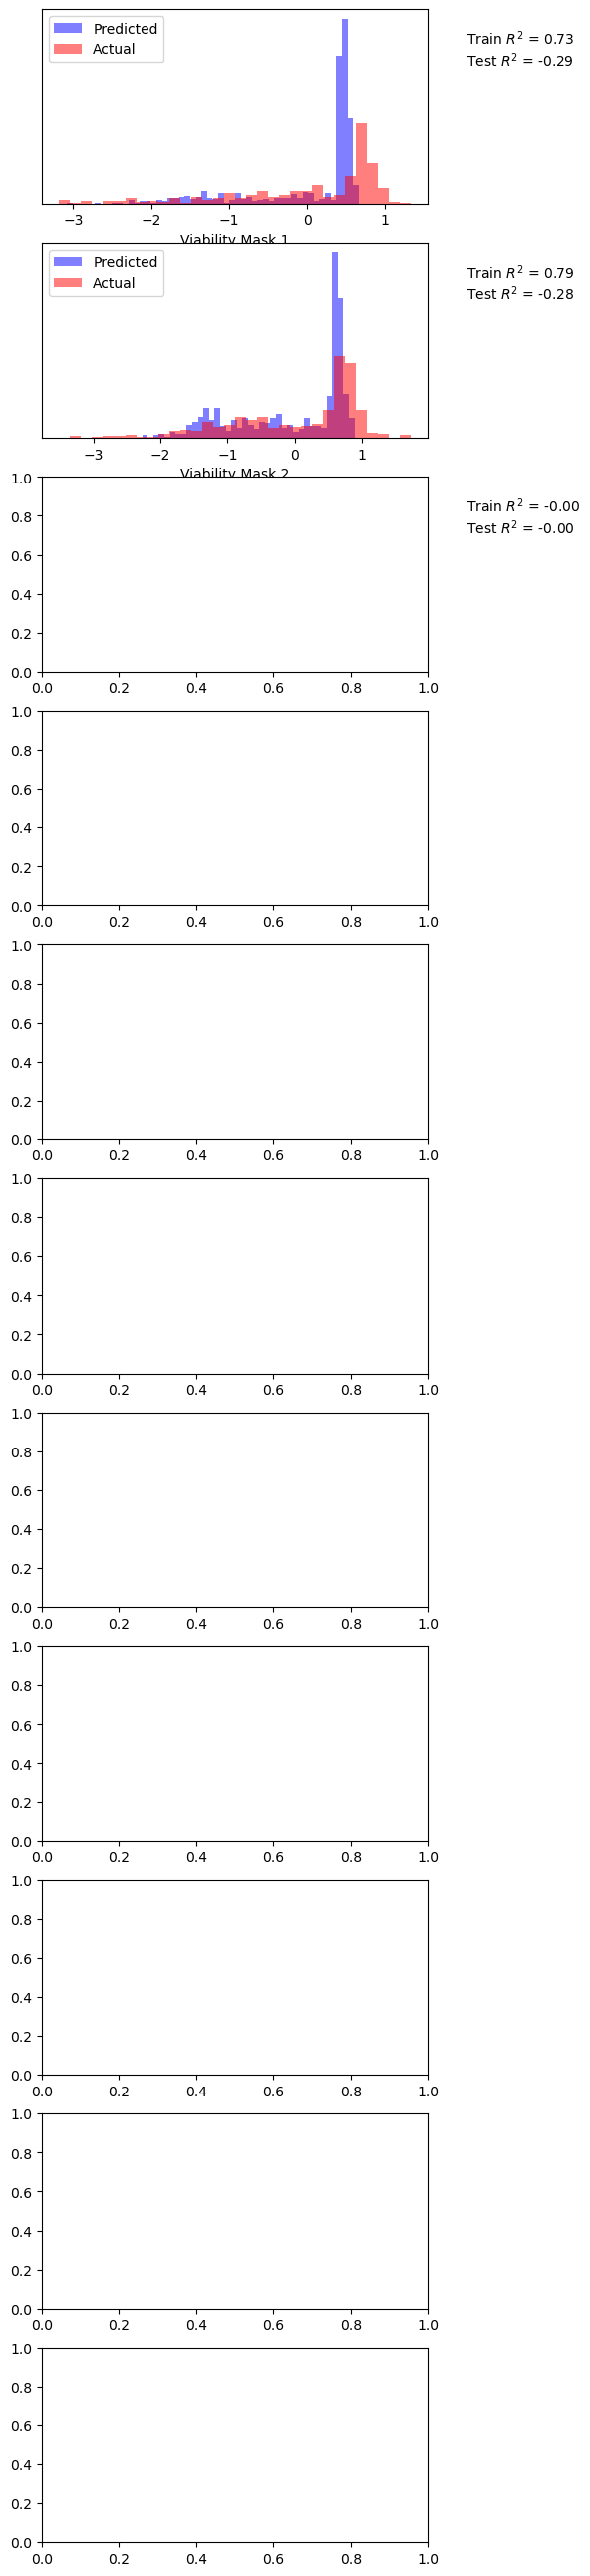

In [6]:
plot_regression_histograms(mlp_dict, train_X, test_X, test, train)